In [19]:
import pandas as pd
df = pd.read_csv("../data/IMDB_Dataset.csv")

df.head(10)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [20]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\Rishabh
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Rishabh
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Rishabh
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Rishabh
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [21]:
df.shape

(50000, 2)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [23]:
#Basic data cleaning 
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove punctuation & numbers
    return text

df["clean_review"] = df["review"].apply(clean_text)

In [25]:
df.head(10)

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tec...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is...
5,"Probably my all-time favorite movie, a story o...",positive,probably my all time favorite movie a story o...
6,I sure would like to see a resurrection of a u...,positive,i sure would like to see a resurrection of a u...
7,"This show was an amazing, fresh & innovative i...",negative,this show was an amazing fresh innovative i...
8,Encouraged by the positive comments about this...,negative,encouraged by the positive comments about this...
9,If you like original gut wrenching laughter yo...,positive,if you like original gut wrenching laughter yo...


In [26]:
# Stop words removal
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = word_tokenize(text)
    filtered = [word for word in words if word not in stop_words]
    return filtered

df["tokens"] = df["clean_review"].apply(remove_stopwords)
df.head(10)

,review,sentiment,clean_review,tokens
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tec...,"[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"[basically, family, little, boy, jake, thinks,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is...,"[petter, mattei, love, time, money, visually, ..."
5,"Probably my all-time favorite movie, a story o...",positive,probably my all time favorite movie a story o...,"[probably, time, favorite, movie, story, selfl..."
6,I sure would like to see a resurrection of a u...,positive,i sure would like to see a resurrection of a u...,"[sure, would, like, see, resurrection, dated, ..."
7,"This show was an amazing, fresh & innovative i...",negative,this show was an amazing fresh innovative i...,"[show, amazing, fresh, innovative, idea, first..."
8,Encouraged by the positive comments about this...,negative,encouraged by the positive comments about this...,"[encouraged, positive, comments, film, looking..."
9,If you like original gut wrenching laughter yo...,positive,if you like original gut wrenching laughter yo...,"[like, original, gut, wrenching, laughter, lik..."


In [27]:
# Lemmatization
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df["lemmatized"] = df["tokens"].apply(lemmatize_words)
df.head(10)

[nltk_data] Downloading package wordnet to C:\Users\Rishabh
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,review,sentiment,clean_review,tokens,lemmatized
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis...","[one, reviewer, mentioned, watching, oz, episo..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tec...,"[wonderful, little, production, filming, techn...","[wonderful, little, production, filming, techn..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"[basically, family, little, boy, jake, thinks,...","[basically, family, little, boy, jake, think, ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is...,"[petter, mattei, love, time, money, visually, ...","[petter, mattei, love, time, money, visually, ..."
5,"Probably my all-time favorite movie, a story o...",positive,probably my all time favorite movie a story o...,"[probably, time, favorite, movie, story, selfl...","[probably, time, favorite, movie, story, selfl..."
6,I sure would like to see a resurrection of a u...,positive,i sure would like to see a resurrection of a u...,"[sure, would, like, see, resurrection, dated, ...","[sure, would, like, see, resurrection, dated, ..."
7,"This show was an amazing, fresh & innovative i...",negative,this show was an amazing fresh innovative i...,"[show, amazing, fresh, innovative, idea, first...","[show, amazing, fresh, innovative, idea, first..."
8,Encouraged by the positive comments about this...,negative,encouraged by the positive comments about this...,"[encouraged, positive, comments, film, looking...","[encouraged, positive, comment, film, looking,..."
9,If you like original gut wrenching laughter yo...,positive,if you like original gut wrenching laughter yo...,"[like, original, gut, wrenching, laughter, lik...","[like, original, gut, wrenching, laughter, lik..."


In [28]:
df["final_text"] = df["lemmatized"].apply(lambda x: " ".join(x))
df.head(10)

,review,sentiment,clean_review,tokens,lemmatized,final_text
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis...","[one, reviewer, mentioned, watching, oz, episo...",one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tec...,"[wonderful, little, production, filming, techn...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...,"[basically, family, little, boy, jake, thinks,...","[basically, family, little, boy, jake, think, ...",basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is...,"[petter, mattei, love, time, money, visually, ...","[petter, mattei, love, time, money, visually, ...",petter mattei love time money visually stunnin...
5,"Probably my all-time favorite movie, a story o...",positive,probably my all time favorite movie a story o...,"[probably, time, favorite, movie, story, selfl...","[probably, time, favorite, movie, story, selfl...",probably time favorite movie story selflessnes...
6,I sure would like to see a resurrection of a u...,positive,i sure would like to see a resurrection of a u...,"[sure, would, like, see, resurrection, dated, ...","[sure, would, like, see, resurrection, dated, ...",sure would like see resurrection dated seahunt...
7,"This show was an amazing, fresh & innovative i...",negative,this show was an amazing fresh innovative i...,"[show, amazing, fresh, innovative, idea, first...","[show, amazing, fresh, innovative, idea, first...",show amazing fresh innovative idea first aired...
8,Encouraged by the positive comments about this...,negative,encouraged by the positive comments about this...,"[encouraged, positive, comments, film, looking...","[encouraged, positive, comment, film, looking,...",encouraged positive comment film looking forwa...
9,If you like original gut wrenching laughter yo...,positive,if you like original gut wrenching laughter yo...,"[like, original, gut, wrenching, laughter, lik...","[like, original, gut, wrenching, laughter, lik...",like original gut wrenching laughter like movi...


In [29]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["final_text"])

In [30]:
y = df["sentiment"]

In [31]:
y = y.map({"positive": 1, "negative": 0})

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
# Model training
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
y_pred = model.predict(X_test)

In [35]:
# Evaluation report 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8891
Precision: 0.8791972211501351
Recall: 0.9041476483429252
F1 Score: 0.8914978964876236


In [36]:
# reviews classified correctly and incorrectly
results = pd.DataFrame({
    "Review": df.loc[y_test.index, "review"],
    "Actual": y_test,
    "Predicted": y_pred
})

# Correct predictions
correct = results[results["Actual"] == results["Predicted"]]

# Incorrect predictions
incorrect = results[results["Actual"] != results["Predicted"]]

print("Correct Predictions:")
print(correct.head(5))

print("\nIncorrect Predictions:")
print(incorrect.head(5))

Correct Predictions:
                                                  Review  Actual  Predicted
9427   Not many television shows appeal to quite as m...       1          1
199    The film quickly gets to a major chase scene w...       0          0
12447  Jane Austen would definitely approve of this o...       1          1
39489  Expectations were somewhat high for me when I ...       0          0
42724  I've watched this movie on a fairly regular ba...       1          1

Incorrect Predictions:
                                                  Review  Actual  Predicted
33553  I really liked this Summerslam due to the look...       1          0
49498  Okay, I didn't get the Purgatory thing the fir...       1          0
29282  This movie starts off somewhat slowly and gets...       1          0
34304  I was first introduced to John Waters films by...       1          0
6113   The production quality, cast, premise, authent...       1          0


The model correctly classified reviews that contained clear sentiment indicators such as strong positive or negative words. However, it struggled with ambiguous or mixed-sentiment reviews, leading to some misclassifications.

In [37]:
# Top positive words and negative words
feature_names = tfidf.get_feature_names_out()

coefficients = model.coef_[0]

top_positive = sorted(zip(coefficients, feature_names), reverse=True)[:10]
top_negative = sorted(zip(coefficients, feature_names))[:10]

print("Top Positive Words:")
print(top_positive)

print("\nTop Negative Words:")
print(top_negative)

Top Positive Words:
[(np.float64(6.995606467159193), 'great'), (np.float64(6.6596594414663945), 'excellent'), (np.float64(5.106823960260268), 'perfect'), (np.float64(4.923114470549252), 'wonderful'), (np.float64(4.85625435522193), 'best'), (np.float64(4.7683581899960865), 'amazing'), (np.float64(4.631188787464024), 'brilliant'), (np.float64(4.4605958690414305), 'favorite'), (np.float64(4.311474100496891), 'loved'), (np.float64(4.170567834906659), 'hilarious')]

Top Negative Words:
[(np.float64(-10.155051420724005), 'worst'), (np.float64(-7.928113151107765), 'waste'), (np.float64(-7.363199125792748), 'awful'), (np.float64(-7.254868048037707), 'bad'), (np.float64(-6.778617083219302), 'boring'), (np.float64(-5.956042575461661), 'poor'), (np.float64(-5.825042249378725), 'terrible'), (np.float64(-5.374080049899084), 'nothing'), (np.float64(-5.061376814230353), 'poorly'), (np.float64(-5.045220616755325), 'dull')]


Positive reviews frequently contain words such as “excellent”, “amazing”, and “great”, indicating strong satisfaction. Negative reviews often include words like “worst”, “boring”, and “poor”, reflecting dissatisfaction. These keywords significantly influence the model’s predictions.

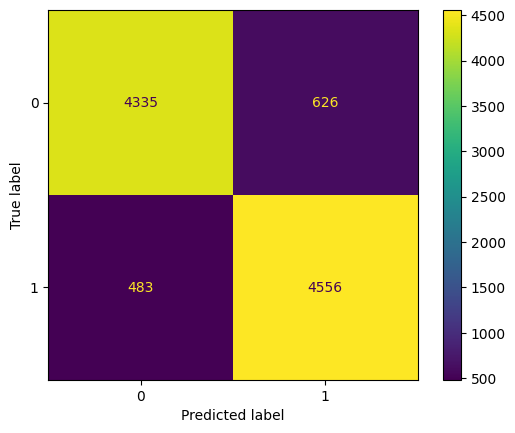

In [38]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#### Interpretation :

Top-left → correct negatives
Bottom-right → correct positives
Others → mistakes

In [ ]:
The confusion matrix shows that the model performs well in distinguishing between positive and negative sentiments, with most predictions falling along the diagonal, indicating correct classifications.

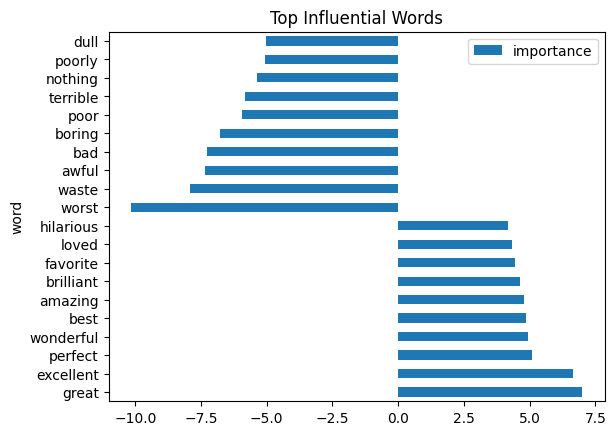

In [40]:
#feature importance
import pandas as pd

coef_df = pd.DataFrame({
    "word": feature_names,
    "importance": coefficients
})

top_words = pd.concat([
    coef_df.sort_values(by="importance", ascending=False).head(10),
    coef_df.sort_values(by="importance").head(10)
])

top_words.plot(kind="barh", x="word", y="importance")
plt.title("Top Influential Words")
plt.show()

### Preprocessing

The dataset was preprocessed by converting text to lowercase, removing punctuation and special characters, eliminating stopwords, and applying tokenization and lemmatization. The cleaned text was then reconstructed for further processing.

### Model Training

TF-IDF vectorization was used to convert text data into numerical form. A Logistic Regression model was trained on the transformed data to classify sentiments as positive or negative.

### Evaluation

The model was evaluated using accuracy, precision, recall, and F1-score. The results indicate that the model performs effectively in classifying sentiments with good balance between precision and recall.